# Clustering and Pattern Analysis 

In [1]:
import tfmindi as tm
import scanpy as sc

In [2]:
# Load preprocessed data from previous tutorial
adata = tm.load_h5ad("seqlets.h5ad")

In [3]:
motif_collection = tm.MotifCollectionData("mcv11.refdata.tar.gz")

In [40]:
motif_collection

Motif Collection Data

Archive file path:
	mcv11.refdata.tar.gz
Annotation for cluster resolutions:
0.1
	0.5
	0.8
	1.0
	1.5
	2.0
	2.5
	3.0
	3.5
PCA data for number of motifs per cluster:
10
	20
	50
	5

## Project seqlets in reference dataset and predict TF family per seqlet

1. Seqlets are projected in the motif collection PCA space.
2. Based on its k-nearest neighbors, each seqlet is annotated to **clusters labels** of the motif collection reference.
3. Cluster labels are linked to TF families.

In [48]:
tm.tl.predict_tf_family_seqlets(
    adata=adata,
    motif_collection=motif_collection,
    cluster_resolution=2.5,
    n_motifs_per_reference_cluster=20,
    batch_size=1_000,
)

KeyboardInterrupt: 

In [49]:
adata.obs[["predicted_2.5_predicted_cluster", "predicted_2.5_predicted_cluster_score", "predicted_2.5_predicted_family"]]

,predicted_2.5_predicted_cluster,predicted_2.5_predicted_cluster_score,predicted_2.5_predicted_family
0,13,1.000000,HMG
1,7,0.865825,zf-C2H2
2,13,1.000000,HMG
3,7,0.599748,zf-C2H2
4,0,1.000000,bHLH
...,...,...,...
679648,7,0.539028,zf-C2H2
679649,38,0.529370,zf-C2H2
679650,38,0.796972,zf-C2H2
679651,138,0.605975,E2F


## Generate tSNE embedding

In [7]:
sc.pp.pca(adata)

In [8]:
sc.pp.neighbors(adata)

/data/groups/vib.ai/stein.aerts/sdewin/PhD/python_modules/TF-MInDi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
sc.tl.tsne(adata)

In [13]:
sc.tl.leiden(adata, resolution=2.5, flavor="igraph")

## Plotting our TF-MINDI clusters

/data/tmp/743728/ipykernel_3655375/2925404557.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = v[s],


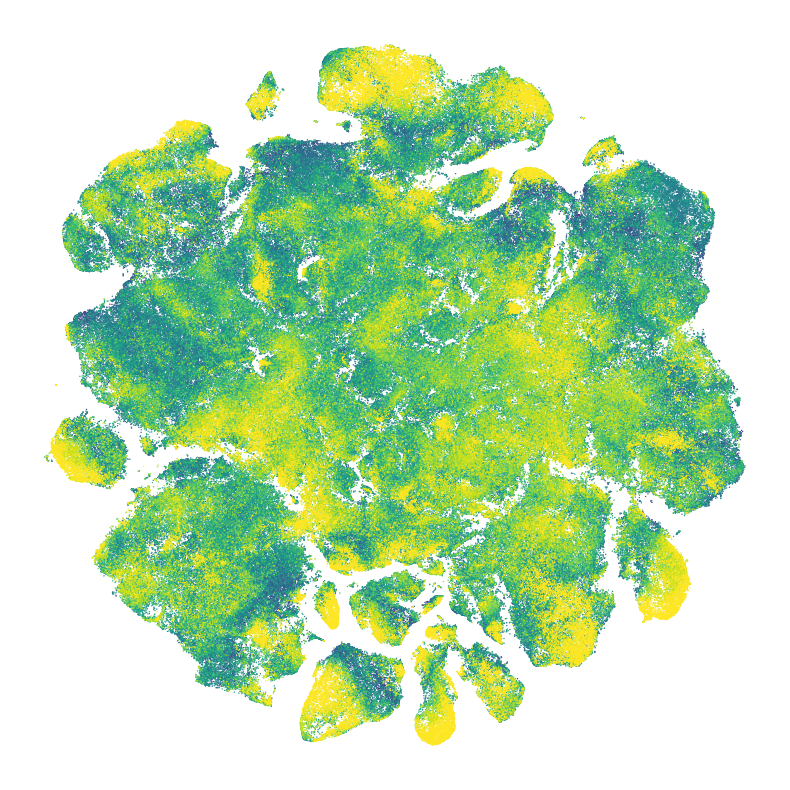

In [50]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# TODO: update TF-MINDI plotting code




fig, ax = plt.subplots(figsize=(8, 8))
X, Y = adata.obsm["X_tsne"].T
v = adata.obs["predicted_2.5_predicted_cluster_score"]
s = np.argsort(v)
ax.scatter(
    X[s], Y[s],
    c = v[s],
    s=1, edgecolors="none"
)
ax.set_axis_off()
fig.tight_layout()
plt.show(fig)


/data/groups/vib.ai/stein.aerts/sdewin/PhD/python_modules/TF-MInDi/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


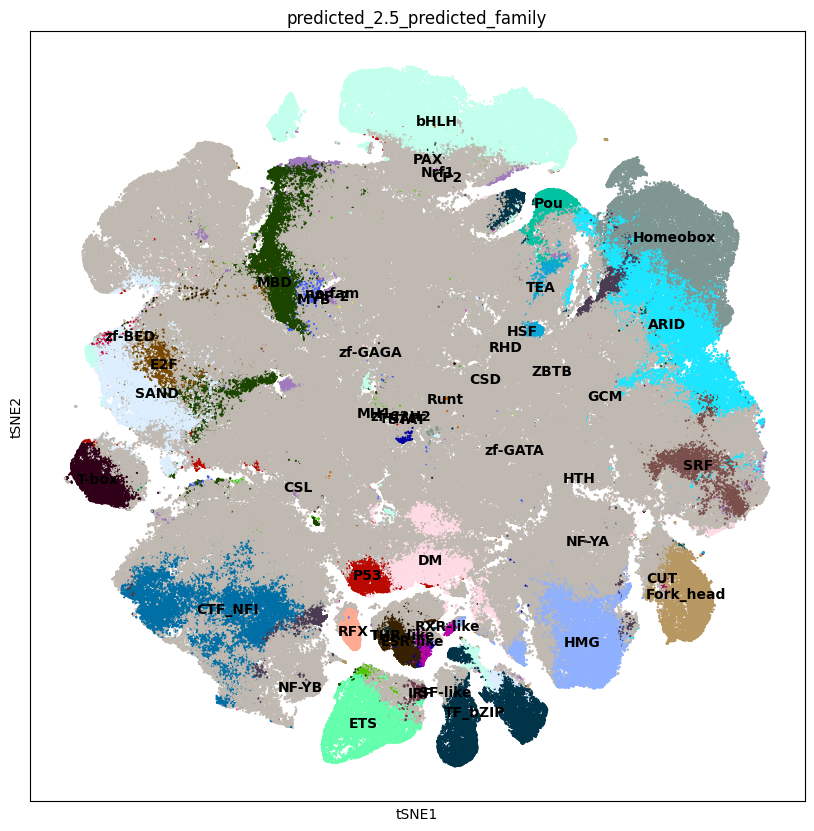

In [51]:
import matplotlib.pyplot as plt
%matplotlib inline

# TODO: update TF-MINDI plotting code


fig, ax = plt.subplots(figsize=(10, 10))
sc.pl.tsne(
    adata[s],
    color="predicted_2.5_predicted_family",
    s=10,
    legend_loc="on data",
    ax=ax
)
plt.show(fig)

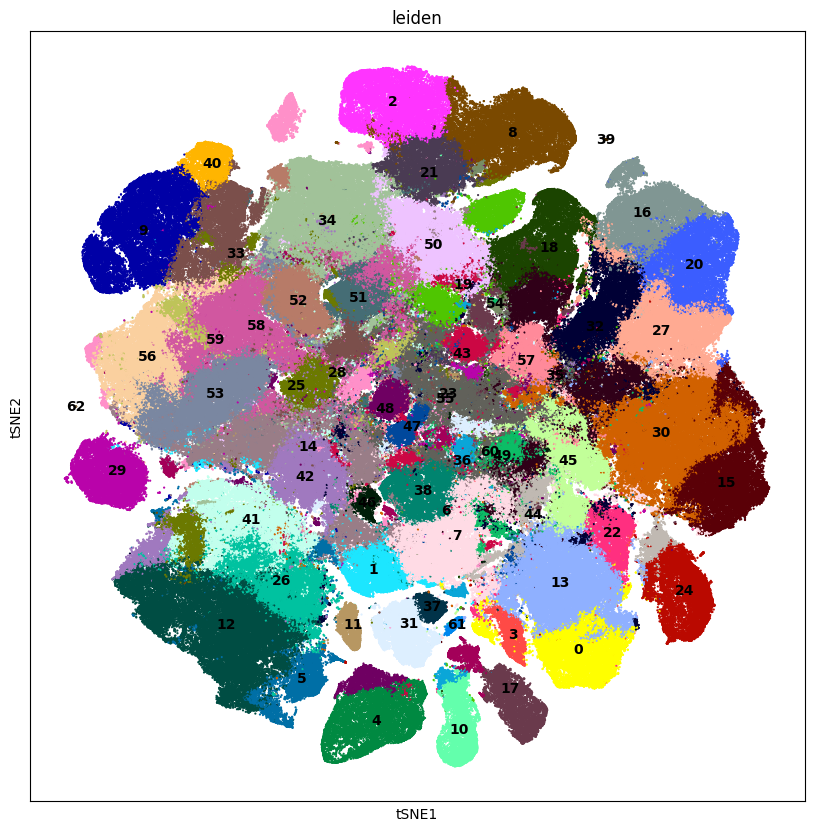

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

# TODO: update TF-MINDI plotting code


fig, ax = plt.subplots(figsize=(10, 10))
sc.pl.tsne(
    adata,
    color="leiden",
    s=10,
    legend_loc="on data",
    ax=ax
)
plt.show(fig)

In [15]:
# TODO: add tf-family per pattern
patterns = tm.tl.create_patterns(
    adata,
    method="tomtom",  # options: 'kmer', 'tomtom'
    max_n=1000,  # sample up to n seqlets per cluster to speed things up
)

Creating patterns for 63 clusters...


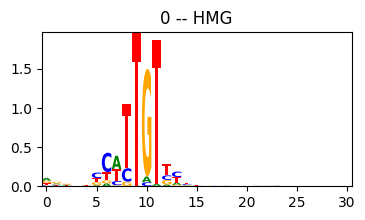

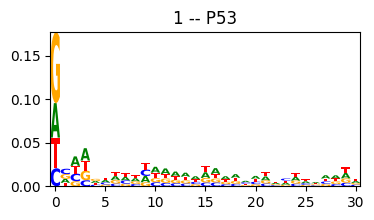

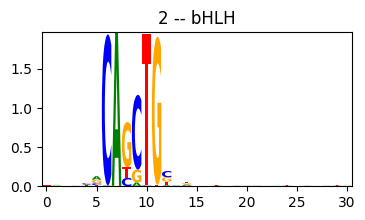

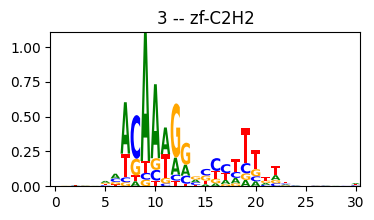

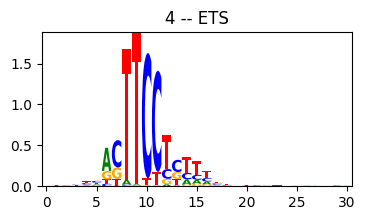

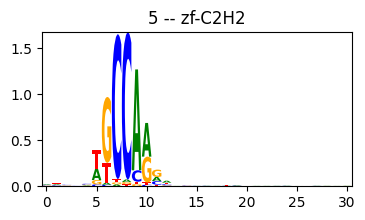

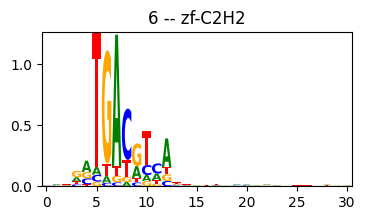

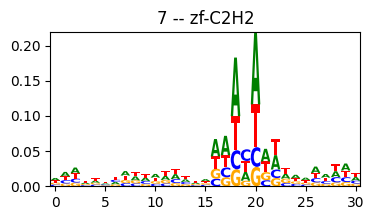

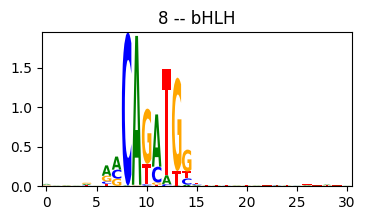

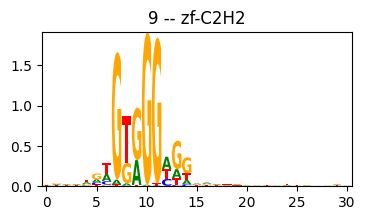

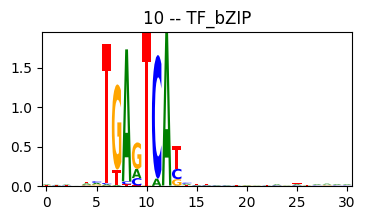

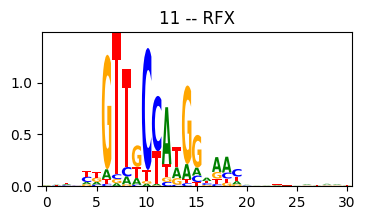

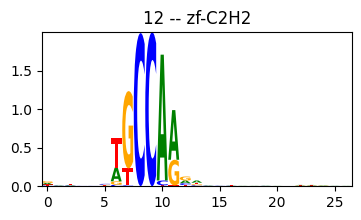

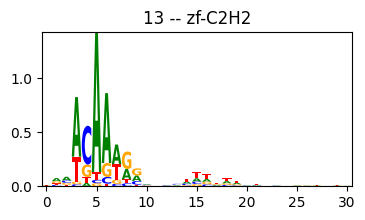

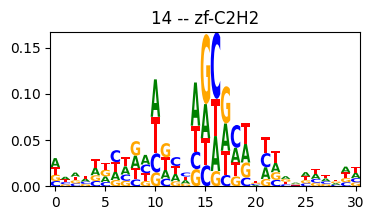

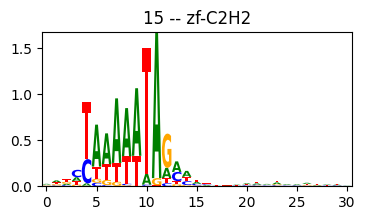

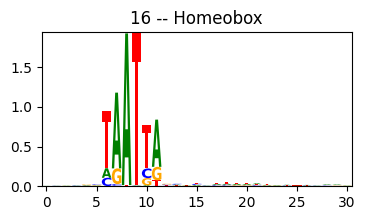

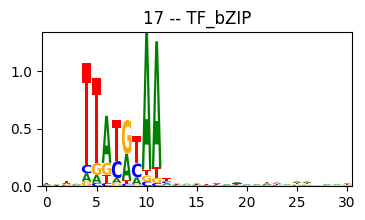

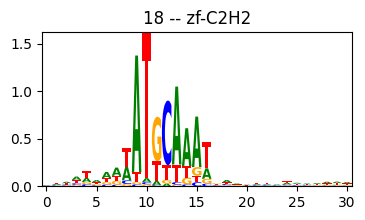

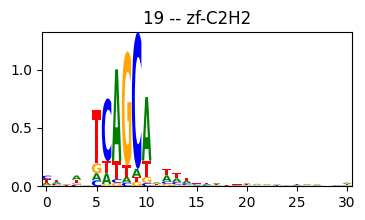

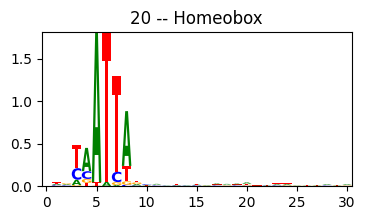

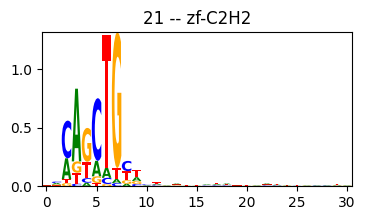

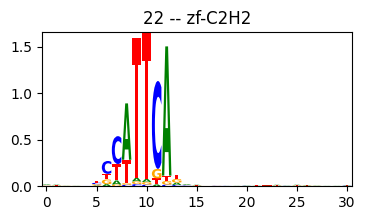

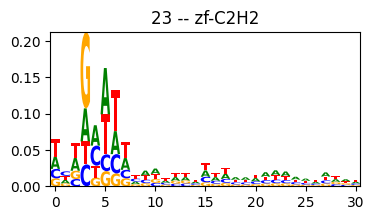

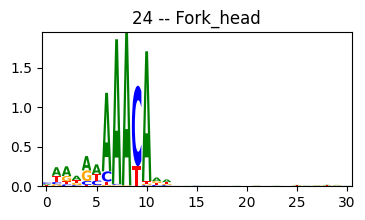

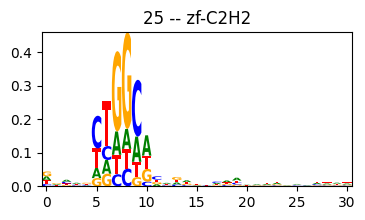

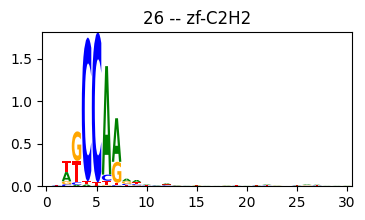

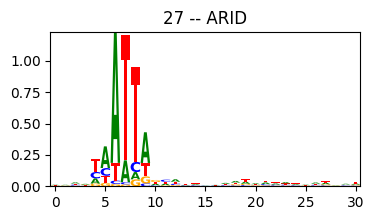

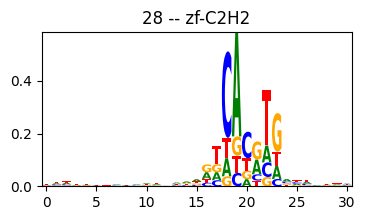

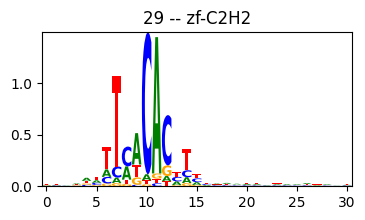

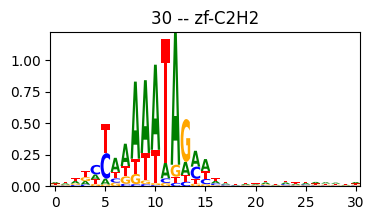

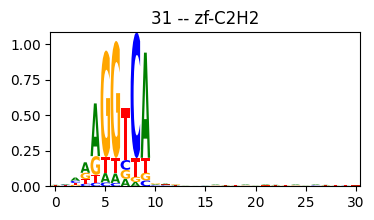

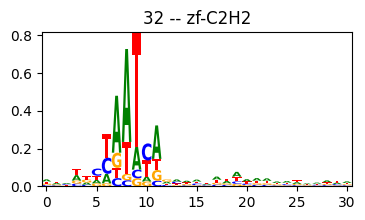

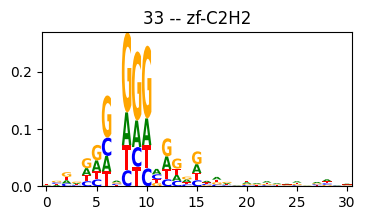

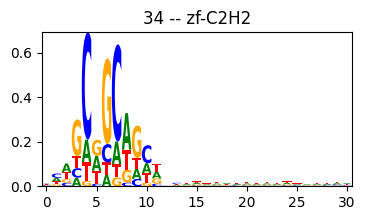

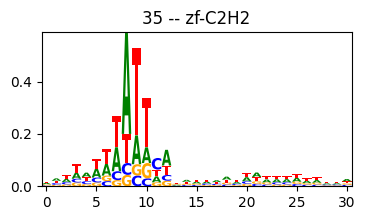

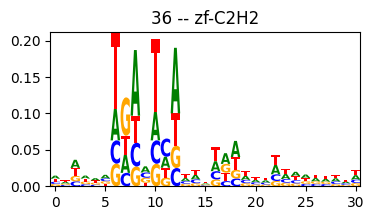

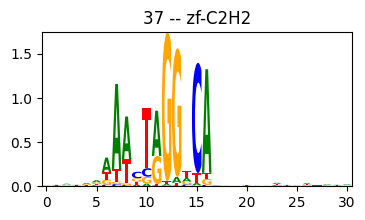

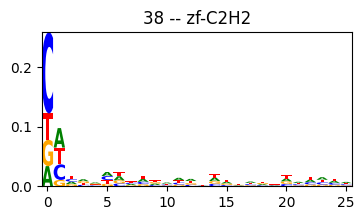

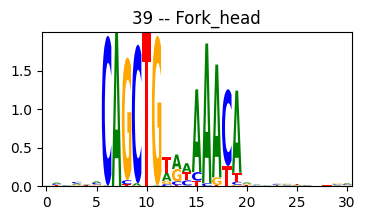

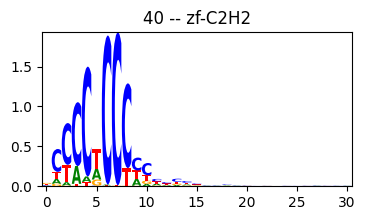

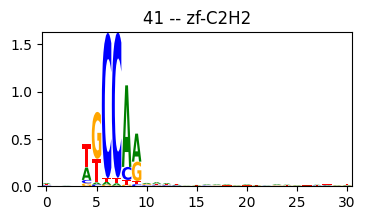

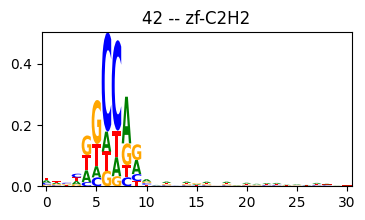

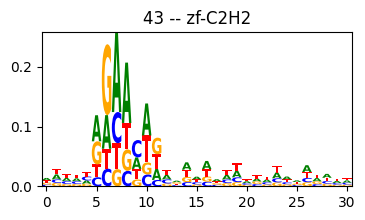

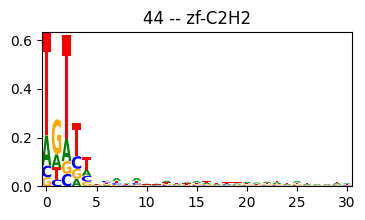

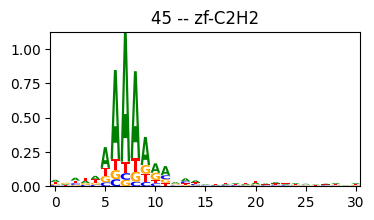

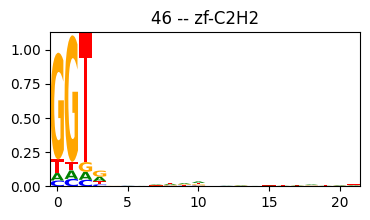

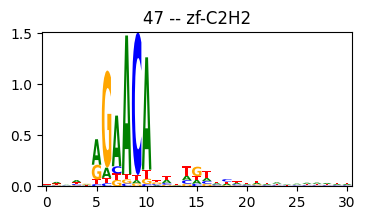

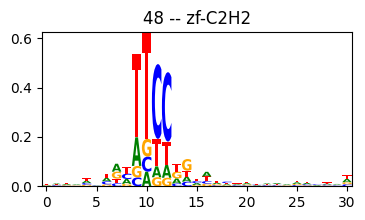

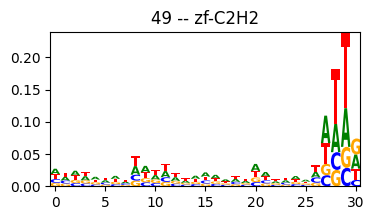

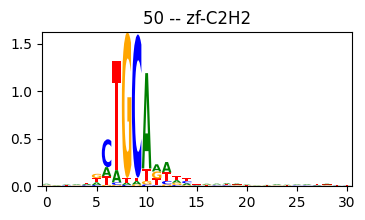

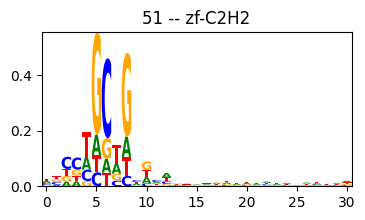

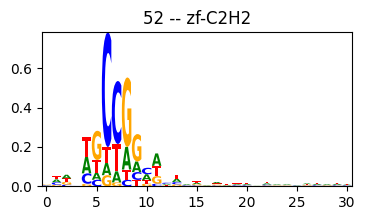

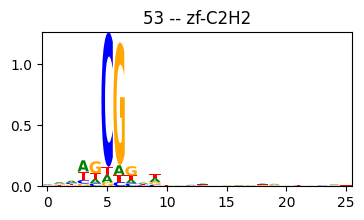

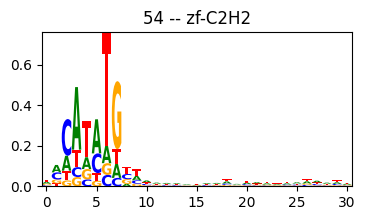

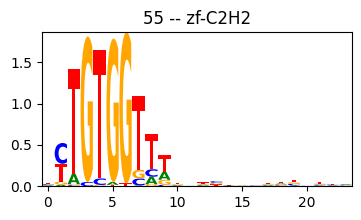

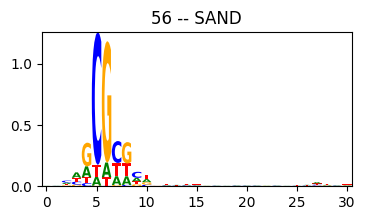

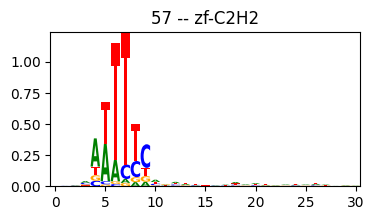

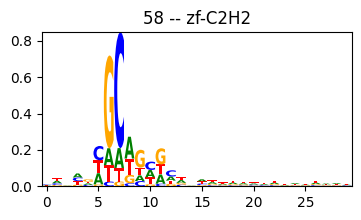

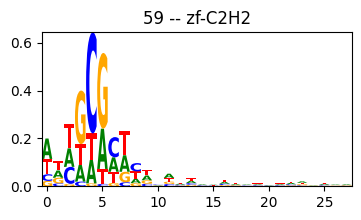

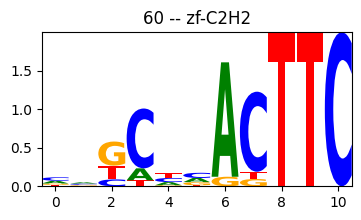

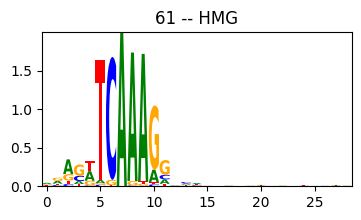

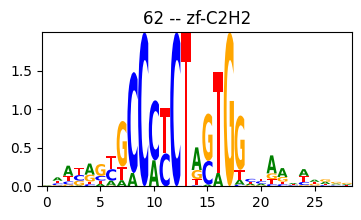

In [28]:
import logomaker
import pandas as pd
for cl in patterns:
    top_fam = adata.obs.loc[adata.obs["leiden"] == cl]["predicted_2.5_predicted_family"].value_counts().index[0]
    fig, ax = plt.subplots(figsize=(4, 2))
    logomaker.Logo(
        pd.DataFrame(
            patterns[cl].ppm * patterns[cl].ic()[:, None],
            columns=list("ACGT")
        ),
        ax=ax
    )
    ax.set_title(f"{cl} -- {top_fam}")
    plt.show(fig)
    plt.close(fig)

```{tip}

You can save patterns using {func}`tfmindi.save_patterns` and load them back using {func}`tfmindi.load_patterns`.
```

'59'

These logo's can now be visualized. For example, on top of the tSNE of seqlets.

We can use a separate {func}`~tfmindi.pl.tsne_logos` to show our previous clusters together with our extracted patterns per cluster.  

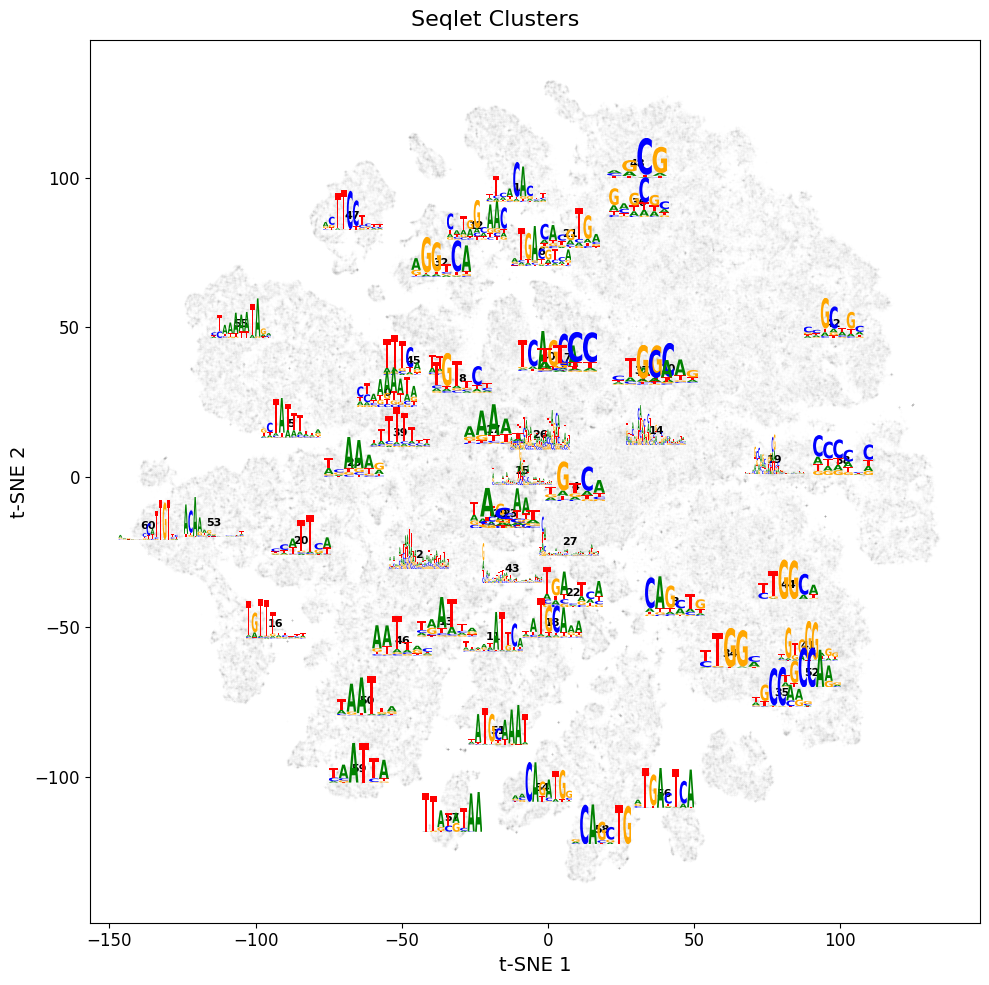

In [12]:
tm.pl.tsne_logos(
    adata,
    patterns,
    gray_background=True,  # ignore cmap and make all points gray for better pattern visibility
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    width=10,
    height=10,
    s=0.3,
    alpha=0.01,  # background alpha
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_seqlets=10,  # ignore patterns with less than this many seqlets in the cluster
)

## Inspecting DNA-Binding Domains

During creation of the consensus patterns cluster, since each cluster has an assigned DNA-Binding Domain (DBD), our patterns were each assigned to a DBD.   
We can visualize the motifs for each of the matched DBD using {func}`~tfmindi.pl.dbd_logos`.  
Since we'll have multiple patterns with the same DBD, for each DBD we visualize one representative logo with the highest information content (IC).   
If a Pattern is too short after trimming for IC content, the next "long enough" pattern will be shown (unless no pattern is long enough). 

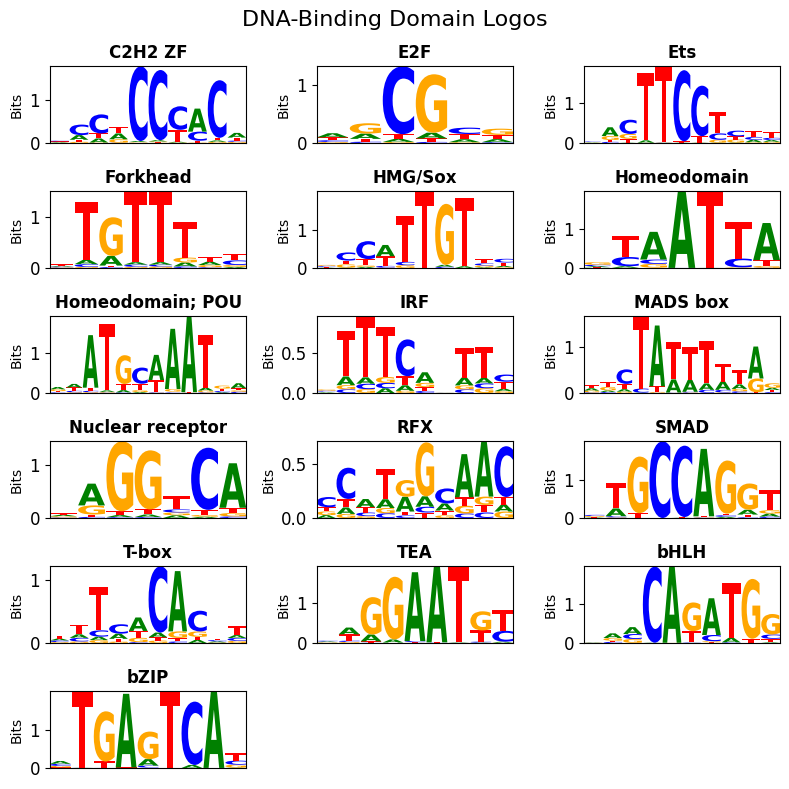

In [6]:
tm.pl.dbd_logos(
    patterns,
    ncols=3,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
)

Alternatively, we can also inspect the heterogeneity of the patterns by plotting the patterns for all clusters of a specific DBD using {func}`~tfmindi.pl.dbd_cluster_logos`.

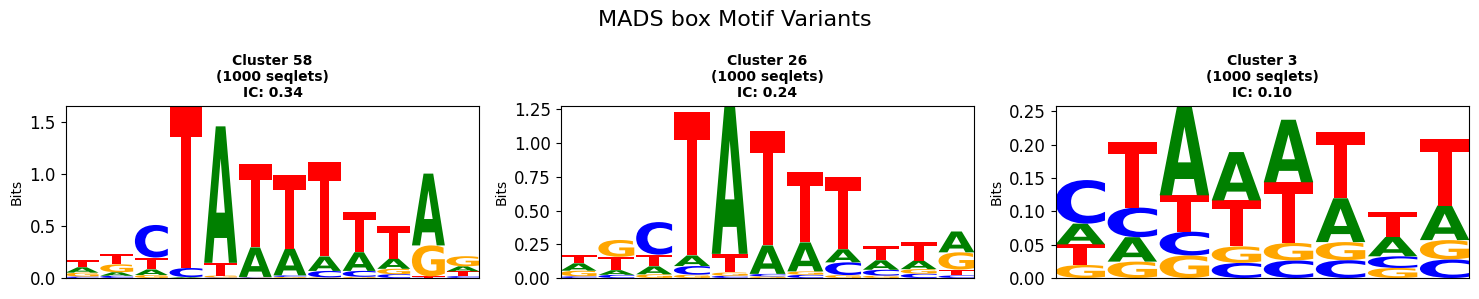

In [9]:
# Let's inspect all assigned MADS box variants
tm.pl.dbd_cluster_logos(
    patterns,
    dbd_name="MADS box",
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    ncols=3,
    width=15,
    height=3,
)

Instead of looking at the DBD motifs per cluster, we can also look the DBD motifs per **cell type**.  
Since each of our regions came from a cell type-specific enhancer and we know which seqlets came from which region, we can count the number of seqlets per DBD assignments and cell type.  
This will show us the DBD-cell type relationship.  
These are best visualized in a heatmap using {func}`~tfmindi.pl.dbd_heatmap`.

/data/groups/vib.ai/stein.aerts/lmahieu/projects/TF-MInDi/src/tfmindi/pl/_utils.py:137: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


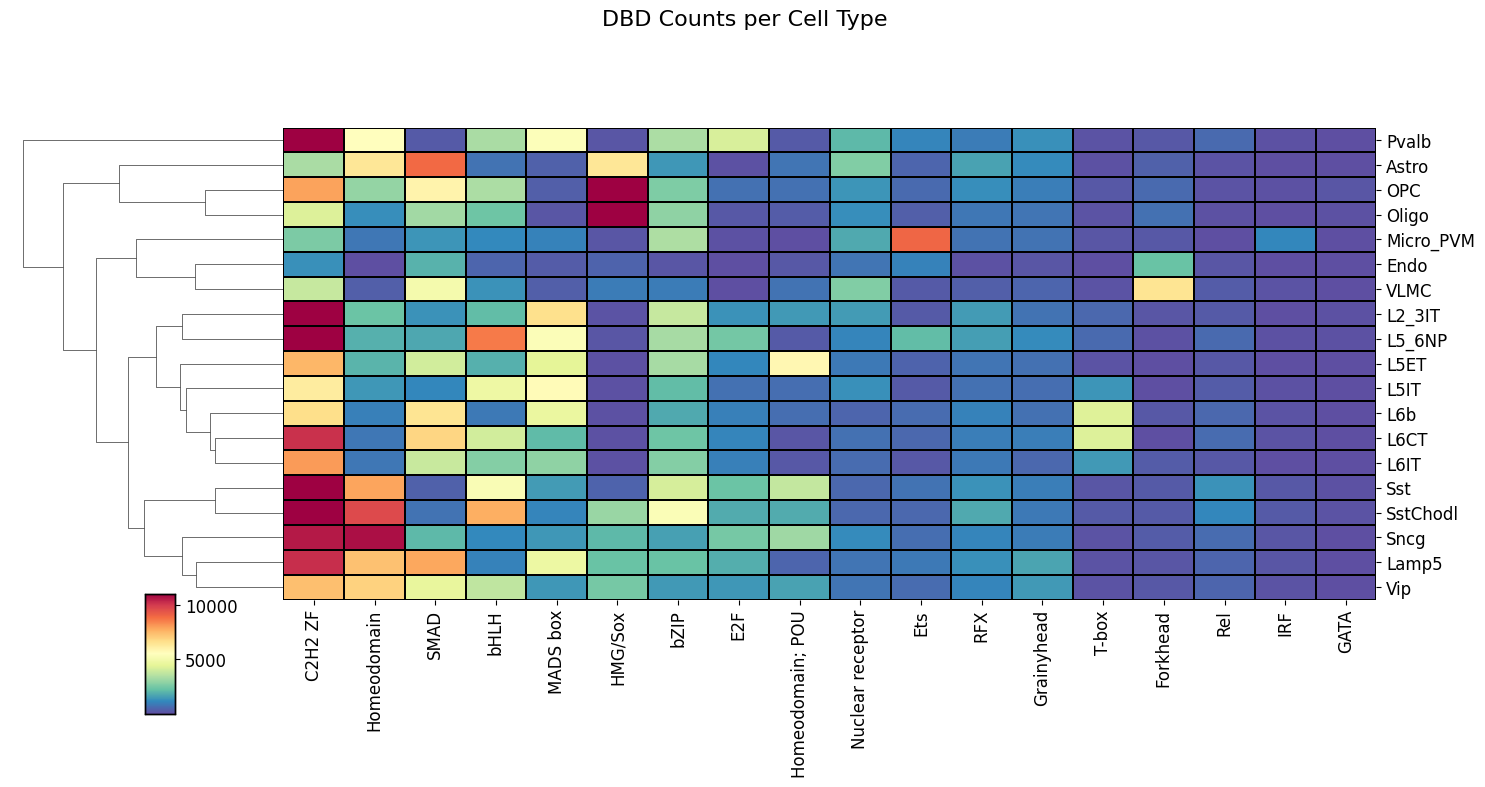

In [15]:
tm.pl.dbd_heatmap(
    adata,
    width=15,
    x_label_rotation=90,
    standard_scale=False,  # set to True to normalize rows accross cell types
    col_cluster=False,  # turn of the DBD clustering
)

## Annotating regions with DBDs

Since we have DBD annotations on a seqlet level after clustering, we can annotate our full regions that we used to extract the seqlets.  
This can be done using {func}`~tfmindi.pl.region_contributions`.

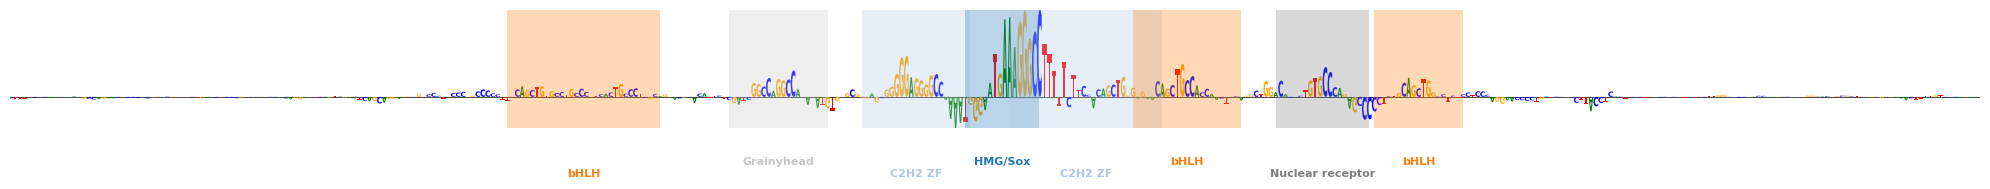

In [16]:
example_idx = 19895  # random region idx
tm.pl.region_contributions(
    adata,
    example_idx=example_idx,
    zoom_start=900,
    zoom_end=1300,  # focus on center 400bp
    min_attribution=3,  # ignore seqlets below this (absolute) threshold
    height=2,
    width=20,
)

Optionally, we can choose to only label certain DBDs.  

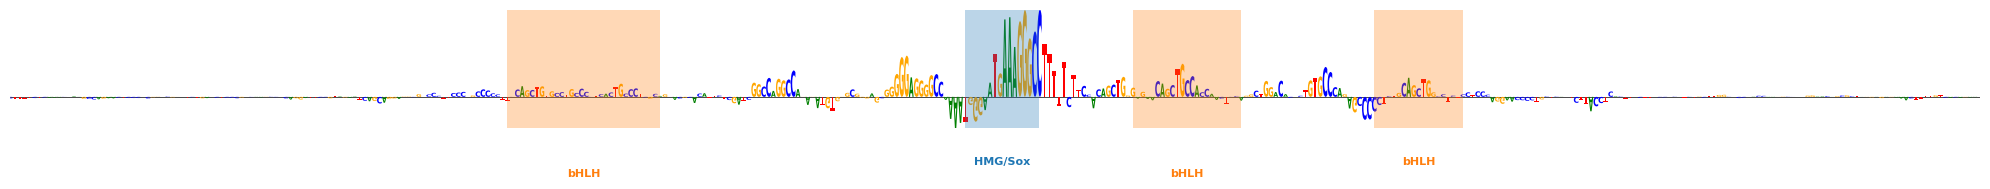

In [17]:
example_idx = 19895  # random region idx
tm.pl.region_contributions(
    adata,
    dbd_names=["HMG/Sox", "bHLH"],  # only show seqlets with these DBDs
    example_idx=example_idx,
    zoom_start=900,
    zoom_end=1300,  # focus on center 400bp
    min_attribution=3,  # ignore seqlets below this (absolute) threshold
    height=2,
    width=20,
)